<a href="https://colab.research.google.com/github/gayatrigbh02/CSL701-CE02-Machine-Learning-Lab/blob/main/ML_EXP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Gayatri Ganpat Bhairavkar
Roll No:CE02

Aim:To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.


TASK 1:
Import libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TASK 2 :Load Auto MPG dataset

In [5]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv('auto-mpg.csv')
df.head()

Saving auto-mpg.csv to auto-mpg (1).csv


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


TASK 3:Inspect and clean data

In [11]:
# Inspect
df.head()
df.info()

# Check missing values
df.isnull().sum()

# Convert to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Check again
df.isnull().sum()

# Remove null rows
df = df.dropna(subset=['horsepower'])

# Final check
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


TASK 4:Select horsepower and mpg


In [15]:
X = df['horsepower']
Y = df['mpg']

TASK 5:Plot scatter graph


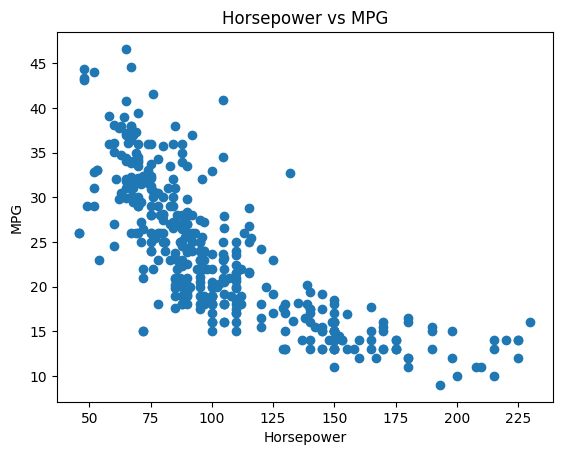

In [16]:
plt.scatter(X, Y)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.show()

TASK 6:Add bias term


In [19]:
X_b = np.c_[np.ones(len(X)), X]

TASK 7:Compute correlation

In [20]:
corr = df['horsepower'].corr(df['mpg'])
print(corr)

-0.7714371350025522


TASK 8:Calculate OLS weights


In [21]:
# Task 8: Calculate OLS Weights

# Select and clean only the required columns
data = df[["horsepower", "mpg"]].copy()

# Convert values to numeric
data["horsepower"] = pd.to_numeric(data["horsepower"], errors="coerce")
data["mpg"] = pd.to_numeric(data["mpg"], errors="coerce")

# Remove missing values
data = data.dropna()

# Define X and y as numeric NumPy arrays
X = data["horsepower"].values.astype(float)
y = data["mpg"].values.astype(float)

# Add bias term
X_bias = np.column_stack((np.ones(len(X)), X))

# Calculate OLS weights using Normal Equation
weights = np.linalg.inv(X_bias.T @ X_bias) @ (X_bias.T @ y)

# Display weights
print("OLS Weights:", weights)

OLS Weights: [40.00451552 -0.15784473]


TASK 9:Predict values


In [24]:
Y_pred = X_b @ weights
residuals = Y - Y_pred

TASK 10:Compute residuals

In [32]:
print("First 5 residuals:")
print(residuals[:5])

First 5 residuals:
0   -1.484700
1    1.039865
2    1.672194
3   -0.327806
4   -0.906253
Name: mpg, dtype: float64


TASK 11:Calculate SSE, MSE, R²

In [28]:
SSE = np.sum(residuals**2)
print("SSE:", SSE)
MSE = SSE / len(Y)
print("MSE:", MSE)
R2 = 1 - (SSE / np.sum((Y - np.mean(Y))**2))
print("R2:", R2)

SSE: 9819.497879931598
MSE: 24.672105225958788
R2: 0.5951152532609462


TASK 12:Plot regression and residual graphs


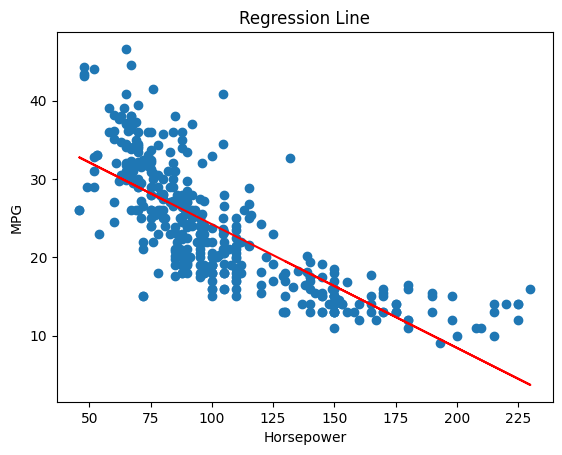

In [29]:
plt.scatter(X, Y)
plt.plot(X, Y_pred, color='red')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Regression Line")
plt.show()

TASK 13:Interpret results.



In [ ]:
#MPG decreases as horsepower increases

#Model shows negative linear relationship

#R² indicates how well model fits data
s
#Residuals are randomly scattered → model is good

Conclusion:
The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
